<a href="https://colab.research.google.com/github/tomasndlate/ai-learning/blob/main/deep_learning_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning - Assignment 1

## Task 1 - Implement Logistic Regression

Classification problem - output the probability (0-1) how likely the output is positive.

Goal is to find a **dividing line** (decision boundary) between classes:
- $ z(x) = (w \times x) + b $, where:
    - $ w $ - weights
    - $ b $ - bias

After finding the **dividing line**, it is needed to apply an **activation function** to convert to a function with $ y $ between 0 and 1.

This way it is possible to predict if an input $ x $ IS (1) or IS NOT (0) a certain class.

Linear Regression -> Logistic Function:
- from -> $ z(x) = (w \times x) + b $
- to -> $ f(z) = \frac{1}{1 + e^{-z}} $

Logistic Regression = Single-Node Neural Network

Import needed libraries:

In [16]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np

In [17]:
# Display plots inline
%matplotlib inline

*This next steps I defined messages that later will redefine inside the Logistic Rgression class - it is easier to follow thinking as a step by step:*

#### Weight Initialisation

Initialise a starting vector of default weights (w) and the Bias (b).


In [18]:
def init_weights_and_bias(num_features):
  w = np.zeros((1, num_features))
  b = 0
  return w, b

#### Sigmoid Function

Probability of data being a specific class (return values between 0 and 1).

Formula -> $ f(z) = \frac{1}{1 + e^{-z}} $

In [19]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

#### Forward Propagation

Calculate linear combination and then pass the result to the sigmoid function to calculate the class probability

$ z(x) = (w \times x) + b $, and use this result in sigmoid function to get a probability 0 to 1

In [20]:
def forward_propagation(w, b, X):
  z = np.dot(w, X) + b
  f = sigmoid(z)
  return f

#### Cost Function - Stochastic Gradient Decent

It compares model predicted label with the true label. Returns how wrong model was.

In [21]:
def cost_function(y, y_pred):
  m = y.shape[1]
  return -(1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

#### Backward Propagation

Calculate the gradients (derivatives). It indicate s the direction and magnitude to reduce error rate

- Weight Gradient: $ dw = \frac{1}{m} X^{T} (A - T) $

- Bias Gradient: $ dw = \frac{1}{m} \sum{(A - T)}  $

In [22]:
def backward_propagation(y, y_pred, X):
  m = y.shape[0]
  dw = (1 / m) * np.dot(X.T, (y_pred - y))
  db = (1 / m) * np.sum(y_pred - y)
  return dw, db

#### Update Parameters

Based on gradient updates the current parameters

In [23]:
def update_parameters(w, b, dw, db, learning_rate):
  w = w - learning_rate * dw
  b = b - learning_rate * db
  return w, b

#### Logistic Regression Model from scratch

In [51]:
class LogisticRegressionScratch:

  def __init__(self):
    self._w = None
    self._b = None

  ## Public methods:

  def train(self, X, y, num_iterations, learning_rate):
    # m - number of samples
    # n - number of features
    m, n = X.shape

    y = y.reshape(-1, 1)

    # initiate weights and bias
    self._w = np.zeros((n, 1))
    self._b = 0

    costs = []
    for i in range(num_iterations):
      y_pred = self.__forward_propagation(X)

      # Cost calculation every 100 iterations
      if i % 100 == 0:
        costs.append(self.__cost_function(y, y_pred))

      dw, db = self.__backward_propagation(y, y_pred, X)

      self.__update_parameters(dw, db, learning_rate)

    print(f"Costs: {costs}")

  def predict(self, X):
    y_pred = self.__forward_propagation(X)
    return (y_pred >= 0.5).astype(int)

  ## Private methods:

  def __forward_propagation(self, X):

    def linear_combination(X):
      return np.dot(X, self._w) + self._b

    def sigmoid(z):
      return 1.0 / (1.0 + np.exp(-z))

    z = linear_combination(X)
    f = sigmoid(z)
    return f

  def __cost_function(self, y, y_pred):
    m = y.shape[0]
    return -(1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

  def __backward_propagation(self, y, y_pred, X):
    m = y.shape[0]
    dw = (1 / m) * np.dot(X.T, (y_pred - y))
    db = (1 / m) * np.sum(y_pred - y)

    return dw, db

  def __update_parameters(self, dw, db, learning_rate):
    self._w -= learning_rate * dw
    self._b -= learning_rate * db


## Task 2 - Testing on Datasets

#### Load Small Datasets

In [50]:
datasets_folder_path = "/content/drive/MyDrive/deep_learning/"

##### Dataset 1 - Blobs 3D

In [52]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv(f"{datasets_folder_path}blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

In [53]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

The dimensions of the dataset are: (600, 3)


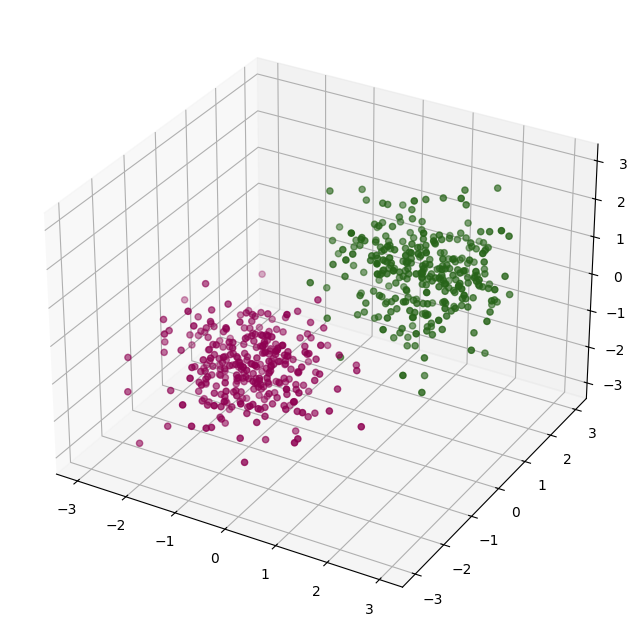

In [54]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

##### Split, Train, Test - Dataset 1

In [55]:
# seed to repeat same random every time I run
np.random.seed(42)

Split dataset:

In [65]:
indices = np.arange(X1.shape[0])
np.random.shuffle(indices)

train_end_index = int(0.7 * len(X1))
val_end_index = int(0.85 * len(X1))

train_idx = indices[:train_end_index]
val_idx = indices[train_end_index:val_end_index]
test_idx = indices[val_end_index:]

X_train, y_train = X1[train_idx], y1[train_idx]
X_val, y_val = X1[val_idx], y1[val_idx]
X_test, y_test = X1[test_idx], y1[test_idx]

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (420, 3)
Validation: (90, 3)
Test: (90, 3)


Train:

In [66]:
model = LogisticRegressionScratch()

model.train(X_train, y_train, num_iterations=1000, learning_rate=0.1)

test_predictions = model.predict(X_test)
accuracy = np.mean(test_predictions.flatten() == y_test.flatten())

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Costs: [np.float64(0.6931471805599453), np.float64(0.06307806181739872), np.float64(0.04244912274816792), np.float64(0.03448814306490307), np.float64(0.030112875502729095), np.float64(0.027293423778870993), np.float64(0.02530212317653918), np.float64(0.023809052258654057), np.float64(0.02264136887888951), np.float64(0.021699115781860023)]
Final Test Accuracy: 100.00%


Test and plot:

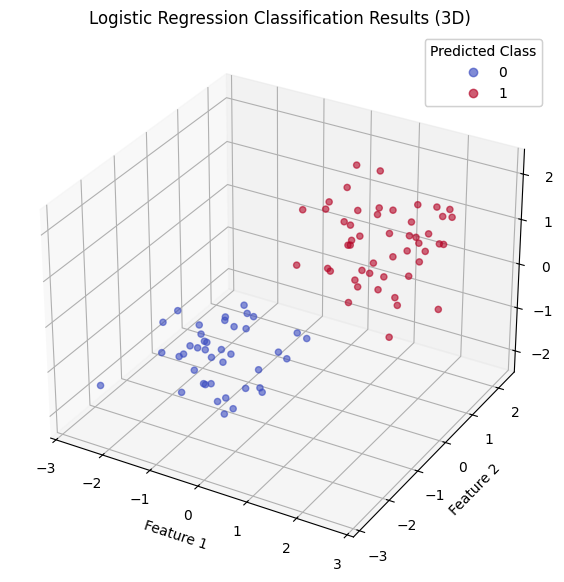

In [61]:
# Predict test dataset
y_pred_total = model.predict(X_test)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(X_test[:,0], X_test[:,1], X_test[:,2], c=y_pred_total.flatten(), cmap="coolwarm", alpha=0.6)

ax.set_title("Logistic Regression Classification Results (3D)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Predicted Class")
ax.add_artist(legend1)

plt.show()

##### Dataset 2 - Circles 2D

In [67]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(f"{datasets_folder_path}circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [68]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

The dimensions of Dataset 2 are: (500, 2)


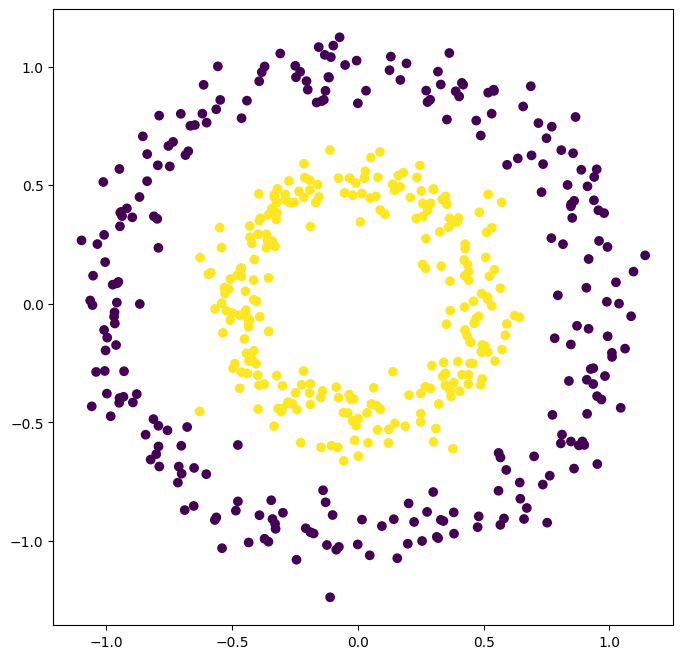

In [69]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

##### Split, Train, Test - Dataset 2

Split dataset:

In [74]:
indices2 = np.arange(X2.shape[0])
np.random.shuffle(indices2)

train_end_index = int(0.7 * len(X2))
val_end_index = int(0.85 * len(X2))

X2_train, y2_train = X2[indices2[:train_end_index]], y2[indices2[:train_end_index]]
X2_val, y2_val = X2[indices2[train_end_index:val_end_index]], y2[indices2[train_end_index:val_end_index]]
X2_test, y2_test = X2[indices2[val_end_index:]], y2[indices2[val_end_index:]]

print(f"Train: {X2_train.shape}")
print(f"Validation: {X2_val.shape}")
print(f"Test: {X2_test.shape}")

Train: (350, 2)
Validation: (75, 2)
Test: (75, 2)


Train:

In [75]:
model2 = LogisticRegressionScratch()

model2.train(X2_train, y2_train, num_iterations=1000, learning_rate=0.1)

Costs: [np.float64(0.6931471805599453), np.float64(0.6918184873027384), np.float64(0.6915449009908674), np.float64(0.6914857249700511), np.float64(0.6914728727321828), np.float64(0.6914700766350942), np.float64(0.6914694676969287), np.float64(0.6914693349905289), np.float64(0.6914693060552952), np.float64(0.6914692997438087)]


Test and plot:

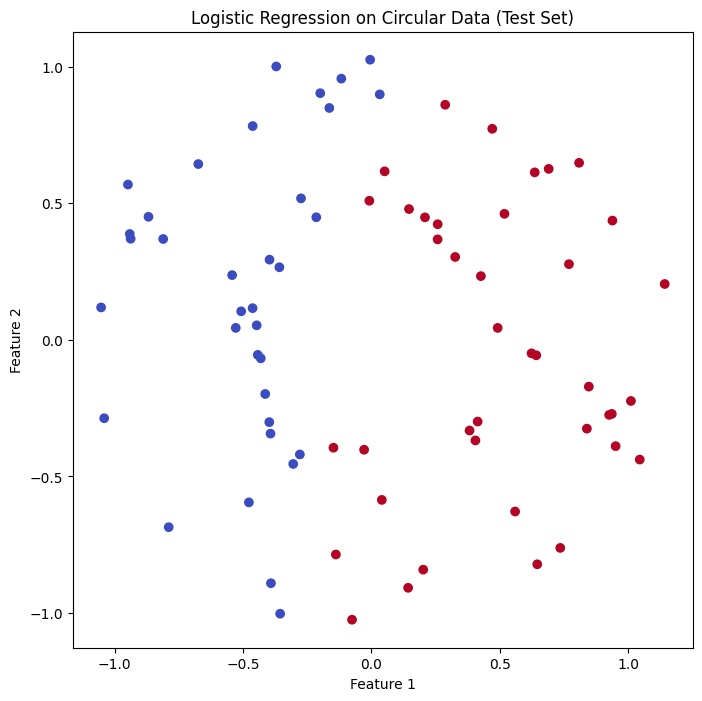

In [77]:
y2_pred = model2.predict(X2_test)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2_test[:,0], X2_test[:,1], c=y2_pred.flatten(), cmap="coolwarm")

ax.set_title("Logistic Regression on Circular Data (Test Set)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

**Observation**: this accuracy is really low compared with the dataset 1 because the logistic regression is limited to linear decision boundaries. In this dataset 2 the data is circular (non-linear).

I know that as mentioned in lectures, there are work around for this type of data, such as transform to the power of 2, but I don't think is the goal of the assignment.

## Task 3 - Implement and Test a Shallow Neural Network

In [81]:
class ShallowNeuralNetwork:

    def __init__(self, num_hidden):
        self.num_hidden = num_hidden
        self._w1, self._b1 = None, None
        self._w2, self._b2 = None, None

    def train(self, X, y, num_iterations, learning_rate):
        m, num_hidden = X.shape
        y = y.reshape(-1, 1)

        # 1. Initialize Parameters (Random is better for NNs to 'break symmetry')
        self._w1 = np.random.randn(num_hidden, self.num_hidden) * 0.01
        self._b1 = np.zeros((1, self.num_hidden))
        self._w2 = np.random.randn(self.num_hidden, 1) * 0.01
        self._b2 = np.zeros((1, 1))

        for i in range(num_iterations):
            # 2. Forward Propagation
            A1, A2 = self.__forward_propagation(X)

            # 3. Backward Propagation
            dw1, db1, dw2, db2 = self.__backward_propagation(X, y, A1, A2)

            # 4. Update Parameters
            self.__update_parameters(dw1, db1, dw2, db2, learning_rate)

            if i % 1000 == 0:
                cost = -(1/m) * np.sum(y * np.log(A2) + (1-y) * np.log(1-A2))
                print(f"Iteration {i}, Cost: {cost}")

    def __forward_propagation(self, X):
        # Hidden layer
        Z1 = np.dot(X, self._w1) + self._b1
        A1 = np.tanh(Z1) # Tanh is standard for hidden layers

        # Output layer
        Z2 = np.dot(A1, self._w2) + self._b2
        A2 = 1 / (1 + np.exp(-Z2)) # Sigmoid for the binary output node
        return A1, A2

    def __backward_propagation(self, X, y, A1, A2):
        m = X.shape[0]

        # Output layer gradients
        dz2 = A2 - y
        dw2 = (1/m) * np.dot(A1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        # Hidden layer gradients (The Chain Rule)
        # derivative of tanh is (1 - A1^2)
        dZ1 = np.dot(dz2, self._w2.T) * (1 - np.power(A1, 2))
        dw1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        return dw1, db1, dw2, db2

    def __update_parameters(self, dw1, db1, dw2, db2, learning_rate):
        self._w1 -= learning_rate * dw1
        self._b1 -= learning_rate * db1
        self._w2 -= learning_rate * dw2
        self._b2 -= learning_rate * db2

    def predict(self, X):
        _, A2 = self.__forward_propagation(X)
        return (A2 >= 0.5).astype(int)

##### Train and Test Dataset 1

In [82]:
# Test on Dataset 1 (Blobs)
# Try a small number of hidden nodes first
nn_blobs = ShallowNeuralNetwork(num_hidden=4)
nn_blobs.train(X_train, y_train, num_iterations=2000, learning_rate=0.1)

# Evaluation
blobs_preds = nn_blobs.predict(X_test)
blobs_acc = np.mean(blobs_preds.flatten() == y_test.flatten())
print(f"Dataset 1 (Blobs) NN Accuracy: {blobs_acc * 100:.2f}%")

Iteration 0, Cost: 0.6931625639979145
Iteration 1000, Cost: 0.014811552798633495
Dataset 1 (Blobs) NN Accuracy: 100.00%


##### Train and Test Dataset 2

In [39]:
# Experiment with Hidden Layer Sizes
hidden_sizes = [2, 4, 10, 20]

for size in hidden_sizes:
    print(f"\n--- Training with {size} Hidden Nodes ---")
    nn_circles = ShallowNeuralNetwork(n_h=size)
    nn_circles.train(X2_train, y2_train, num_iterations=5000, learning_rate=0.5)

    # Check Validation Accuracy to see which 'size' is best
    val_preds = nn_circles.predict(X2_val)
    val_acc = np.mean(val_preds.flatten() == y2_val.flatten())
    print(f"Nodes: {size} | Validation Accuracy: {val_acc * 100:.2f}%")


--- Training with 2 Hidden Nodes ---
Iteration 0, Cost: 0.6931464130612006
Iteration 1000, Cost: 0.5430447900798269
Iteration 2000, Cost: 0.4285338913814103
Iteration 3000, Cost: 0.42009566911364987
Iteration 4000, Cost: 0.41653009746945135
Nodes: 2 | Validation Accuracy: 76.00%

--- Training with 4 Hidden Nodes ---
Iteration 0, Cost: 0.693146874140625
Iteration 1000, Cost: 0.5328801838637053
Iteration 2000, Cost: 0.08643861945688497
Iteration 3000, Cost: 0.051166294012185407
Iteration 4000, Cost: 0.037211112562826096
Nodes: 4 | Validation Accuracy: 100.00%

--- Training with 10 Hidden Nodes ---
Iteration 0, Cost: 0.6931518313277898
Iteration 1000, Cost: 0.6568674762283794
Iteration 2000, Cost: 0.07820684840838224
Iteration 3000, Cost: 0.045005508638770876
Iteration 4000, Cost: 0.03275494487152738
Nodes: 10 | Validation Accuracy: 100.00%

--- Training with 20 Hidden Nodes ---
Iteration 0, Cost: 0.6931411421001912
Iteration 1000, Cost: 0.5283147829368124
Iteration 2000, Cost: 0.0697872

## Task 4 - Tackle a Challenging Task

#### Load EMNIST Letters

In [40]:
data = np.load(f"{datasets_folder_path}emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [41]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


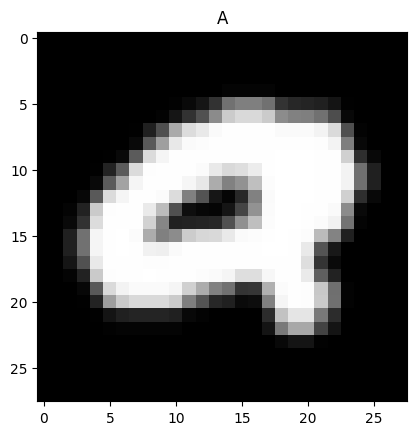

In [42]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))
plt.show()

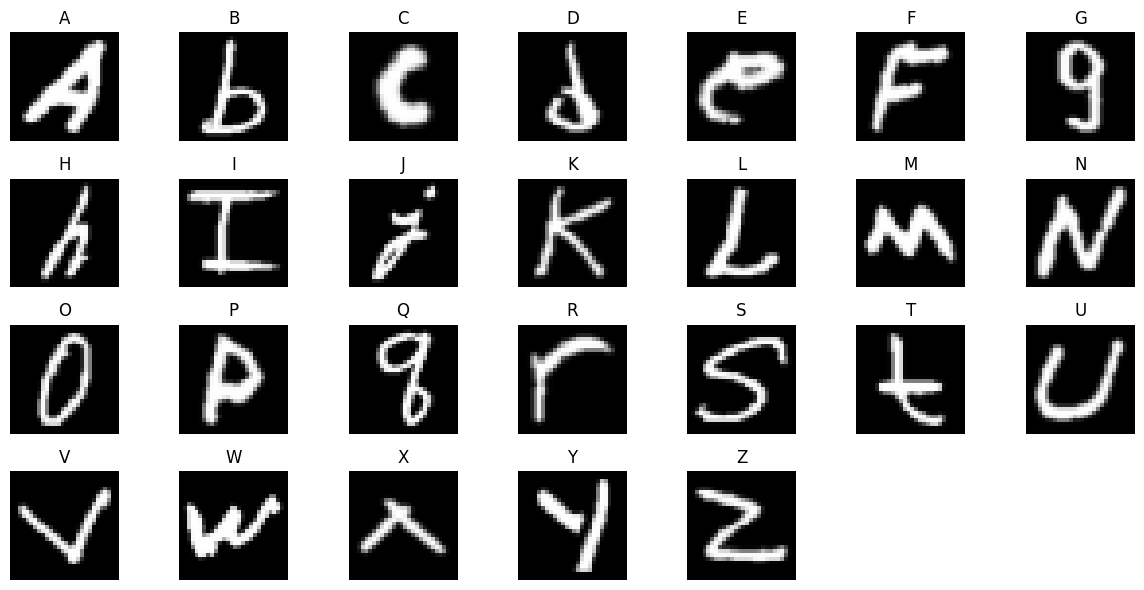

In [43]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    # Find first index of this class
    idx = np.where(y_data == cls)[0][n]

    plt.subplot(4, 7, i + 1)
    plt.imshow(x_data[idx].squeeze(), cmap="gray")
    plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 2   # example
c2 = 25  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [45]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))

    for i in range(48):
        idx = n + i

        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

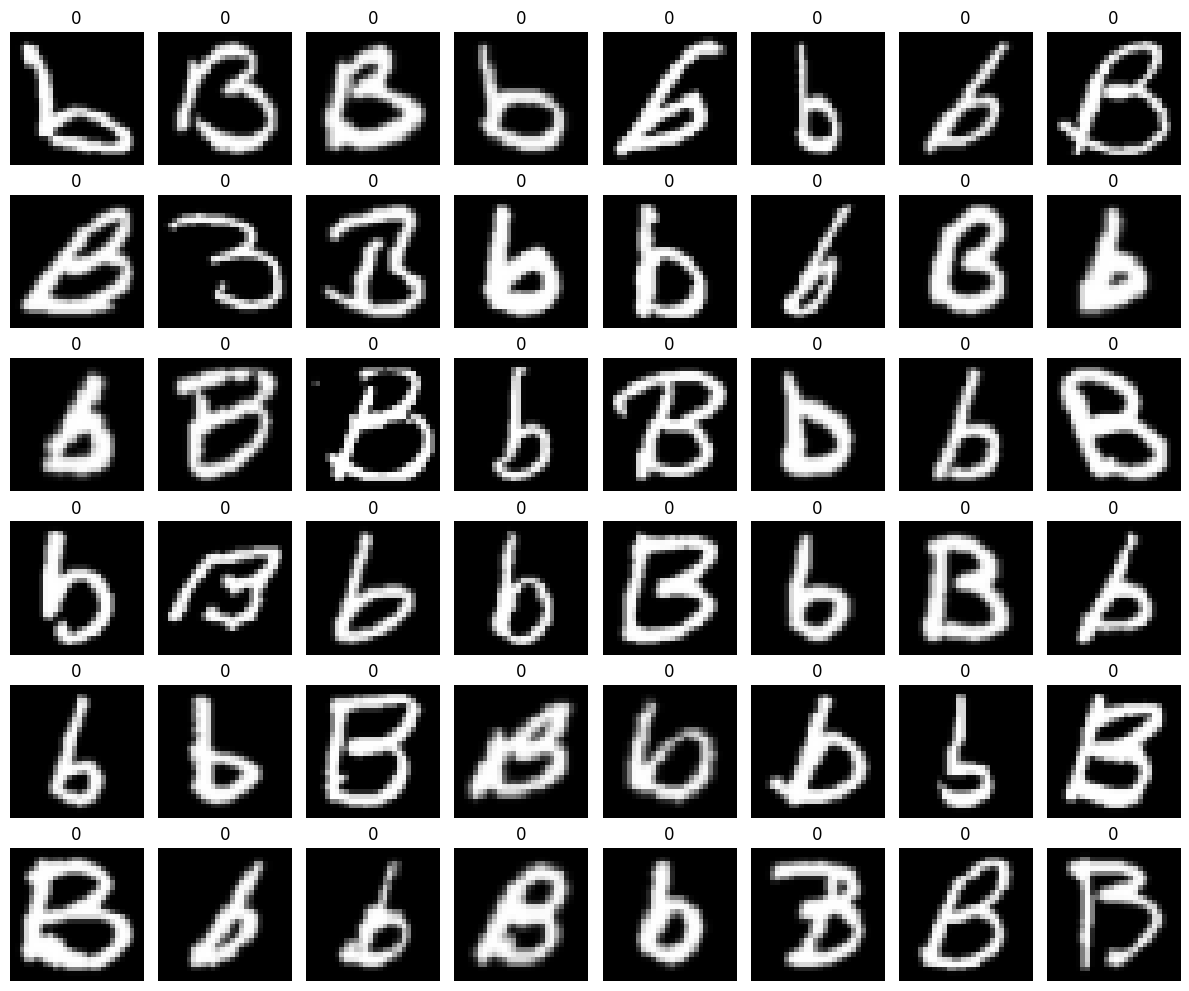

In [46]:
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

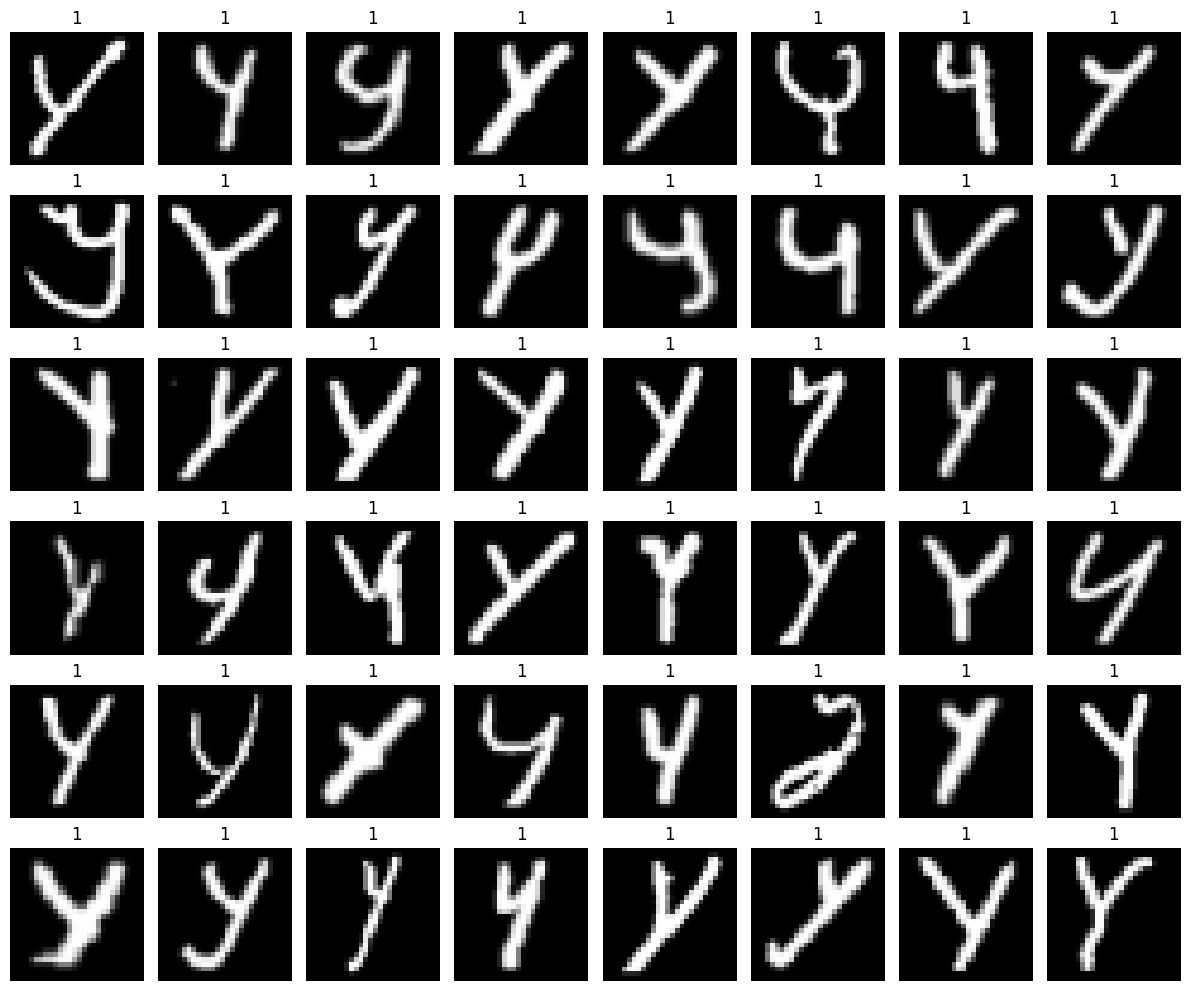

In [47]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

##### Pre-process and Split data

In [48]:
# 1. Flatten the images from (28, 28, 1) to (784,)
X_task4 = x_binary.reshape(x_binary.shape[0], -1)

# 2. Ensure y is the correct shape
Y_task4 = y_binary.reshape(-1, 1)

print(f"New shape of X: {X_task4.shape}") # Should be (6600, 784)

np.random.seed(42)
indices = np.arange(X_task4.shape[0])
np.random.shuffle(indices)

train_end = int(0.7 * len(X_task4))
val_end = int(0.85 * len(X_task4))

X_letter_train, y_letter_train = X_task4[indices[:train_end]], Y_task4[indices[:train_end]]
X_letter_val, y_letter_val = X_task4[indices[train_end:val_end]], Y_task4[indices[train_end:val_end]]
X_letter_test, y_letter_test = X_task4[indices[val_end:]], Y_task4[indices[val_end:]]

New shape of X: (6600, 784)


##### Train

In [49]:
# Initialize with more hidden nodes
nn_letters = ShallowNeuralNetwork(n_h=128)

# Train the model
# You might need more iterations (e.g., 5000+) for images
nn_letters.train(X_letter_train, y_letter_train, num_iterations=5000, learning_rate=0.05)

Iteration 0, Cost: 0.6910793584104188
Iteration 1000, Cost: 0.05128994242894121
Iteration 2000, Cost: 0.03906614470555585


KeyboardInterrupt: 

In [ ]:
# Predict on the held-out test set
y_letter_pred = nn_letters.predict(X_letter_test)

# Calculate Accuracy
# We flatten both to ensure they are the same shape (N,)
accuracy = np.mean(y_letter_pred.flatten() == y_letter_test.flatten())

print(f"Task 4 Final Accuracy on Letters: {accuracy * 100:.2f}%")

In [ ]:
# Example of how to plot after training
plt.plot(costs)
plt.title("Training Curve - Letter Recognition")
plt.xlabel("Iterations (x100)")
plt.ylabel("Cost")
plt.show()

## Task 5 - Deep Learning Enhancements

No Time to

## Resources Used

- [Logistic Regression From Scratch in Python (Mathematical)](https://youtu.be/S6iuhdYsGC8?si=h1A8BCT3nPreHwj_) - explain all maths behind logistic regression algorithm

- [Neural Network from Scratch | Mathematics & Python](https://youtu.be/pauPCy_s0Ok?si=ABtqppnJDxMaiGgb) - explain maths behind neural networks from scratch